# Rainfall Box-Mean vs Nino-3.4 Using Centered 3-Month Running Mean

This notebook tests whether focusing on DJF is justified by correlating the monthly MSWEP rainfall box mean against monthly Nino-3.4 after removing the monthly climatology and applying a centered 3-month running mean.

## Scope

- Rainfall box: 95E-125E, 6S-2N.
- Use the exact rectangle already present in the older code.
- January corresponds to the DJF-centered 3-month window, February to JFM, and so on.
- The series is padded with December 1980 and January 2021 so the centered mean is valid over 1981-2020.

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)

START_YEAR = 1981
END_YEAR = 2020

TARGET_BOX = {
    "lon_min": 95.0,
    "lon_max": 125.0,
    "lat_min": -6.0,
    "lat_max": 2.0,
}

PROJECT_ROOT = Path("/Users/rizzie/TugasAkhir/data_processing")
MSWEP_PATH = PROJECT_ROOT / "external/ClimateData/mswep-monthly/mswep_monthly_combined.nc"
NINO34_PATH = PROJECT_ROOT / "external/ClimateData/index-monthly/nino34.anom.csv"

LOAD_START = pd.Timestamp(START_YEAR - 1, 12, 1)
LOAD_END = pd.Timestamp(END_YEAR + 1, 1, 31)
ANALYSIS_START = pd.Timestamp(START_YEAR, 1, 1)
ANALYSIS_END = pd.Timestamp(END_YEAR, 12, 31)

MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
SEASON_WINDOWS = ["DJF", "JFM", "FMA", "MAM", "AMJ", "MJJ", "JJA", "JAS", "ASO", "SON", "OND", "NDJ"]

In [6]:
def standardize_rainfall_da(da: xr.DataArray) -> xr.DataArray:
    rename_map = {}
    if "latitude" in da.dims or "latitude" in da.coords:
        rename_map["latitude"] = "lat"
    if "longitude" in da.dims or "longitude" in da.coords:
        rename_map["longitude"] = "lon"
    if "valid_time" in da.dims or "valid_time" in da.coords:
        rename_map["valid_time"] = "time"
    if rename_map:
        da = da.rename(rename_map)

    da = da.assign_coords(time=pd.to_datetime(da["time"].values)).sortby("time")
    da = da.assign_coords(lon=(da["lon"] % 360)).sortby("lon")
    return da


def subset_box(da: xr.DataArray, box: dict) -> xr.DataArray:
    lon_min = float(min(box["lon_min"], box["lon_max"]))
    lon_max = float(max(box["lon_min"], box["lon_max"]))
    lat_min = float(min(box["lat_min"], box["lat_max"]))
    lat_max = float(max(box["lat_min"], box["lat_max"]))

    lat_ascending = float(da["lat"].values[0]) < float(da["lat"].values[-1])
    lon_ascending = float(da["lon"].values[0]) < float(da["lon"].values[-1])

    lat_slice = slice(lat_min, lat_max) if lat_ascending else slice(lat_max, lat_min)
    lon_slice = slice(lon_min, lon_max) if lon_ascending else slice(lon_max, lon_min)
    sub = da.sel(lat=lat_slice, lon=lon_slice)

    if sub.sizes.get("lat", 0) == 0 or sub.sizes.get("lon", 0) == 0:
        raise ValueError(f"Empty rainfall subset for box={box}")
    return sub


def area_weighted_monthly_mean(da_box: xr.DataArray) -> pd.Series:
    weights = xr.DataArray(
        np.cos(np.deg2rad(da_box["lat"])),
        coords={"lat": da_box["lat"]},
        dims=("lat",),
    )
    monthly = da_box.weighted(weights).mean(dim=("lat", "lon"), skipna=True).to_series()
    monthly.index = pd.to_datetime(monthly.index)
    monthly = monthly.sort_index().groupby(monthly.index.to_period("M")).mean()
    monthly.index = monthly.index.to_timestamp(how="start")
    return monthly.rename("rain_box")


def load_nino34_monthly(path: Path) -> pd.Series:
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    date_col = next((c for c in df.columns if c.lower() == "date"), None)
    if date_col is None:
        raise ValueError(f"No Date column found in {path}")

    value_col = next(c for c in df.columns if c != date_col)
    out = df[[date_col, value_col]].copy()
    out["time"] = pd.to_datetime(out[date_col], errors="coerce")
    out["nino34"] = pd.to_numeric(out[value_col], errors="coerce").replace([-99.99, -9999, -9999.0], np.nan)
    out = out.dropna(subset=["time"])
    out["time"] = out["time"].dt.to_period("M").dt.to_timestamp(how="start")
    out = out.groupby("time", as_index=False)["nino34"].mean().sort_values("time")
    series = out.set_index("time")["nino34"].rename("nino34")
    return series


def monthly_anomaly_series(series: pd.Series, start_year: int, end_year: int) -> pd.Series:
    s = series.copy()
    s.index = pd.to_datetime(s.index)
    base = s.loc[f"{start_year}-01-01":f"{end_year}-12-31"]
    climatology = base.groupby(base.index.month).mean()
    anomaly = s - pd.Index(s.index.month).map(climatology).to_numpy()
    anomaly.name = series.name
    return anomaly


def centered_running_mean_frame(df: pd.DataFrame) -> pd.DataFrame:
    return df.rolling(window=3, center=True, min_periods=3).mean()


def corr_with_p(x: np.ndarray, y: np.ndarray):
    ok = np.isfinite(x) & np.isfinite(y)
    x_ok = x[ok]
    y_ok = y[ok]
    if x_ok.size < 3:
        return np.nan, np.nan, int(x_ok.size)
    if np.isclose(np.std(x_ok), 0.0) or np.isclose(np.std(y_ok), 0.0):
        return np.nan, np.nan, int(x_ok.size)
    r, p_value = pearsonr(x_ok, y_ok)
    return float(r), float(p_value), int(x_ok.size)

In [7]:
if not MSWEP_PATH.exists():
    raise FileNotFoundError(f"MSWEP file not found: {MSWEP_PATH}")
if not NINO34_PATH.exists():
    raise FileNotFoundError(f"Nino3.4 file not found: {NINO34_PATH}")

print(f"Using MSWEP: {MSWEP_PATH}")
print(f"Using Nino-3.4: {NINO34_PATH}")
print(f"Using rainfall box: {TARGET_BOX}")

# 2) Load monthly MSWEP rainfall and monthly Nino-3.4
ds_rain = xr.open_dataset(MSWEP_PATH)
rain_var = "precipitation" if "precipitation" in ds_rain.data_vars else list(ds_rain.data_vars)[0]
rain = standardize_rainfall_da(ds_rain[rain_var])
nino_monthly = load_nino34_monthly(NINO34_PATH)

# Keep the monthly span needed for centered 3-month means.
rain = rain.sel(time=slice("1980-12-01", "2021-01-31"))
nino_monthly = nino_monthly.loc["1980-12-01":"2021-01-01"]

# 3) Subset rainfall to box and compute area-weighted monthly box mean
rain_box = subset_box(rain, TARGET_BOX)
rain_box_monthly = area_weighted_monthly_mean(rain_box)

monthly = pd.concat([rain_box_monthly, nino_monthly], axis=1).sort_index()

print("Rainfall path:", MSWEP_PATH)
print("Nino3.4 path:", NINO34_PATH)
print(f"Rain box shape: lat={rain_box.sizes['lat']}, lon={rain_box.sizes['lon']}")
print(f"Monthly frame span: {monthly.index.min().date()} to {monthly.index.max().date()}")
print(f"Monthly frame columns: {list(monthly.columns)}")
print(f"Non-null monthly pairs: {monthly.dropna().shape[0]}")

Using MSWEP: /Users/rizzie/TugasAkhir/data_processing/external/ClimateData/mswep-monthly/mswep_monthly_combined.nc
Using Nino-3.4: /Users/rizzie/TugasAkhir/data_processing/external/ClimateData/index-monthly/nino34.anom.csv
Using rainfall box: {'lon_min': 95.0, 'lon_max': 125.0, 'lat_min': -6.0, 'lat_max': 2.0}
Rainfall path: /Users/rizzie/TugasAkhir/data_processing/external/ClimateData/mswep-monthly/mswep_monthly_combined.nc
Nino3.4 path: /Users/rizzie/TugasAkhir/data_processing/external/ClimateData/index-monthly/nino34.anom.csv
Rain box shape: lat=80, lon=300
Monthly frame span: 1980-12-01 to 2021-01-01
Monthly frame columns: ['rain_box', 'nino34']
Non-null monthly pairs: 482


In [8]:
rain_anom = monthly_anomaly_series(monthly["rain_box"], START_YEAR, END_YEAR)
nino_anom = monthly_anomaly_series(monthly["nino34"], START_YEAR, END_YEAR)
anomalies = pd.concat([rain_anom, nino_anom], axis=1)
rm3 = centered_running_mean_frame(anomalies)

analysis = rm3.loc[ANALYSIS_START:ANALYSIS_END]

print("Centered 3-month anomalies prepared.")
print(f"Analysis span: {analysis.index.min().date()} to {analysis.index.max().date()}")
print(f"Analysis rows with both series present: {analysis.dropna().shape[0]}")

Centered 3-month anomalies prepared.
Analysis span: 1981-01-01 to 2020-12-01
Analysis rows with both series present: 480


In [9]:
results = []
for month in range(1, 13):
    subset = analysis.loc[analysis.index.month == month].dropna()
    r, p_value, n = corr_with_p(
        subset["rain_box"].to_numpy(),
        subset["nino34"].to_numpy(),
    )
    results.append(
        {
            "month": month,
            "month_name": MONTH_NAMES[month - 1],
            "season_window": SEASON_WINDOWS[month - 1],
            "r": r,
            "p_value": p_value,
            "n": n,
        }
    )

results_df = pd.DataFrame(results)

summary_df = results_df[["month_name", "season_window", "r", "p_value"]].copy()
summary_df.columns = ["Month", "Season Window", "r", "p-value"]
summary_df["r"] = summary_df["r"].map(lambda v: f"{v:.4f}" if np.isfinite(v) else "nan")
summary_df["p-value"] = summary_df["p-value"].map(lambda v: f"{v:.4f}" if np.isfinite(v) else "nan")

print("\nMonthly 3-month running-mean correlation summary (1981-2020)")
print(summary_df.to_string(index=False))


Monthly 3-month running-mean correlation summary (1981-2020)
Month Season Window       r p-value
  Jan           DJF -0.3909  0.0126
  Feb           JFM -0.3177  0.0458
  Mar           FMA -0.3811  0.0152
  Apr           MAM -0.2454  0.1270
  May           AMJ -0.1992  0.2179
  Jun           MJJ -0.5059  0.0009
  Jul           JJA -0.7188  0.0000
  Aug           JAS -0.7680  0.0000
  Sep           ASO -0.7909  0.0000
  Oct           SON -0.7645  0.0000
  Nov           OND -0.7264  0.0000
  Dec           NDJ -0.5155  0.0007


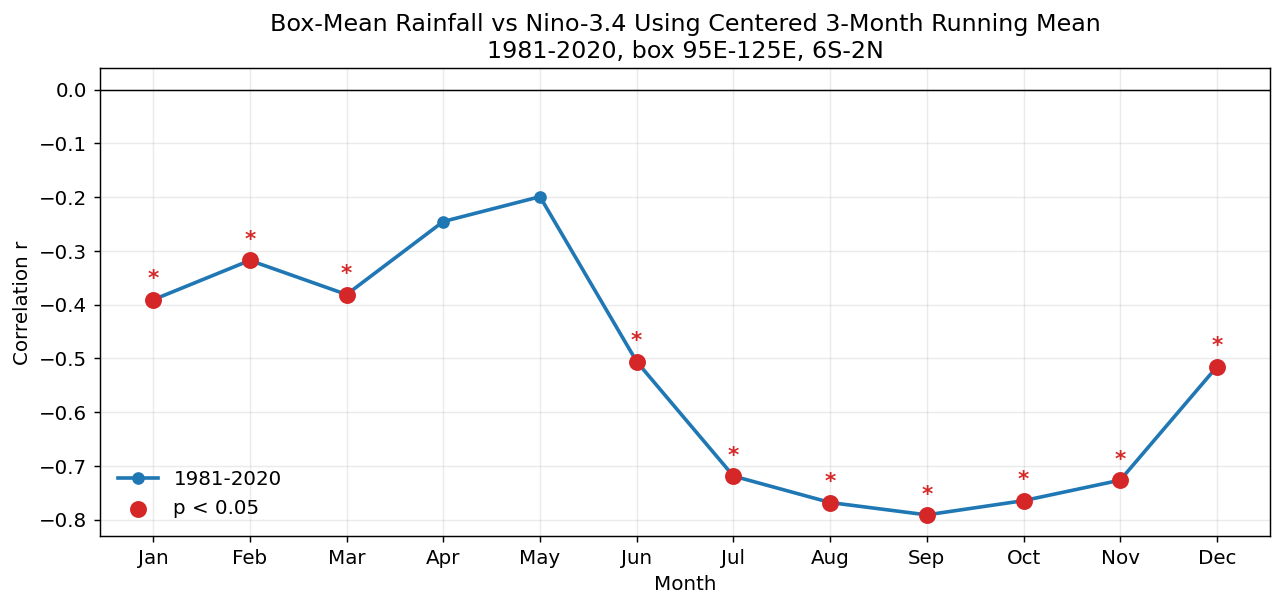

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    results_df["month"],
    results_df["r"],
    color="tab:blue",
    marker="o",
    linewidth=2,
    label="1981-2020",
)

sig = results_df["p_value"] < 0.05
ax.scatter(
    results_df.loc[sig, "month"],
    results_df.loc[sig, "r"],
    color="tab:red",
    s=70,
    zorder=3,
    label="p < 0.05",
)

for _, row in results_df.loc[sig].iterrows():
    ax.annotate(
        "*",
        (row["month"], row["r"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        color="tab:red",
        fontsize=12,
        fontweight="bold",
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_NAMES)
ax.set_xlabel("Month")
ax.set_ylabel("Correlation r")
ax.set_title(
    "Box-Mean Rainfall vs Nino-3.4 Using Centered 3-Month Running Mean\n"
    "1981-2020, box 95E-125E, 6S-2N"
)
ax.legend(frameon=False)
ax.grid(True, axis="y")
fig.tight_layout()
plt.show()

In [11]:
valid = results_df.dropna(subset=["r"])
if not valid.empty:
    strongest = valid.loc[valid["r"].idxmin()]
    print(
        "Strongest negative correlation: "
        f"{strongest['month_name']} ({strongest['season_window']})\n"
        f"r = {strongest['r']:.4f}, p-value = {strongest['p_value']:.4f}"
    )

Strongest negative correlation: Sep (ASO)
r = -0.7909, p-value = 0.0000
